# Tercile Hit Rate Analysis of Climate Models

Notes and Todos at the end of the document

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
from collections import defaultdict

# define list missing months function
def list_missing_files(file_path):
  """This function takes a model file path, such as the GFDL model, and lists
  the missing months and years in the file names.

  For example, if the year 1997 had the missing month of September, the
  function will print '1997 missing Sep'.

  Additionally, if the entire year of 1999 is missing, it will print '1999 missing entirely'.

  Assumptions
  -----------
  Assumes that the path given to the function leads to a folder that has files
  with naming convention similar to 'prec.GFDL-SPEAR.1997.mon_Aug.nc'

  This function slices the last part of the file name to get the year and month
  information. It ignores the "front" part of the file name. So, in theory, as long
  as the format is 'some_variable.some_model_name.YYYY.mon_MMM.nc', this function will
  be able to check all missing months.

  Dependencies
  ------------
  Make sure to import the os module and the defaultdict object using these import statements.
  These are native to python and require no additional installation.

  import os
  from collections import defaultdict
  """

  # use os module to list all file names
  file_list = os.listdir(file_path)

  # Extract year and month info from filenames
  # for the GFDL model, the file names are in the format of 'prec.GFDL-SPEAR.1997.mon_Aug.nc'
  # Thus, the year and month are indexed by file_name[16:20] and file_name[25:28] respectively

  # define year_month dictionary
  year_month_dict = defaultdict(set)

  full_year_set = set(range(1991, 2025))

  years_available = []

  for file in file_list:
      if len(file) >= 28:  # Ensure the filename is long enough
          year = file[-15:-11]  # Extract year (e.g., "2024")
          month = file[-6:-3]  # Extract month (e.g., "Sep")
          year_month_dict[year].add(month)
          years_available.append(year)

  # Define the complete set of months
  full_month_set = {'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'}

  # Check for missing months
  for year, months in year_month_dict.items():
      missing_months = full_month_set - months  # Find missing months
      if missing_months:
          missing_str = ', '.join(sorted(missing_months))
          print(f"{year} missing {missing_str}")

  # check for missing years

  for year in full_year_set:
    if str(year) not in years_available:
      print(f"{year} missing entirely")

# Example usage

# Define the file path of GFDL model
file_path = '/content/drive/My Drive/capstone_data/NMME/GFDL-SPEAR/prec'

# call the function
list_missing_files(file_path)

2025 missing Apr, Aug, Dec, Feb, Jul, Jun, Mar, May, Nov, Oct, Sep
2020 missing Apr, Aug, Feb, Jan, Jul, Jun, Mar, May, Nov, Oct, Sep
1997 missing Sep
1999 missing entirely
2000 missing entirely
2001 missing entirely
2002 missing entirely
2003 missing entirely
2004 missing entirely
2005 missing entirely
2006 missing entirely
2007 missing entirely
2008 missing entirely
2009 missing entirely
2010 missing entirely
2011 missing entirely
2012 missing entirely
2013 missing entirely
2014 missing entirely
2015 missing entirely
2016 missing entirely
2017 missing entirely
2018 missing entirely
2019 missing entirely


In [ ]:
# Set index to be reindex to

# -90 to 90, with 0.5 degree resolution latitude
# -180 to 180 with 0.5 degree resolution longitude
new_lat = np.arange(-90, 90, 0.5)
new_lon = np.arange(-180, 180, 0.5)

In [ ]:
# open chirps dataset
chirps = xr.open_dataset('/content/drive/My Drive/capstone_data/CHIRPS/chirps-v2.0.monthly.nc')

In [ ]:
# open GFDL dataset
GFDL = xr.open_mfdataset('/content/drive/My Drive/capstone_data/NMME/GFDL-SPEAR/prec/*.nc', parallel=True)

# regrid to have same latitude and longitude as chirps
GFDL = GFDL.assign_coords(X=(((GFDL.X + 180) % 360) - 180)).sortby(['X'])

# reindex to 0.5 degree resolution, using the latitude and longitude ranges previously defined (chirps)
GFDL = GFDL.reindex(X=new_lon, Y=new_lat).ffill('X').ffill('Y')

# Attempt to run tercile hit rate for South Sudan Region GFDL

Only use years 1993 to 2020

Currently, for GFDL, there is missing data between 1998 and 2020 on the google drive

In [ ]:
# Subset the South Sudan Region GFDL
GFDL_south_sudan = (GFDL.sel(Y=slice(3.5, 12.5), X=slice(25, 35))
                       .rename({'Y': 'latitude', 'X': 'longitude', 'prec': 'predicted_precip', 'S': 'date_of_prediction', 'L': 'lead_time'}))

# Interpolate and subset CHIRPS to match spatial resolution of GFDL
chirps_south_sudan = chirps.sel(latitude=slice(3,13), longitude=slice(24.5,35.5)).interp_like(GFDL_south_sudan, method='nearest')

In [ ]:
# Took 5 mins to run on colab
# Calculate realized dates for GFDL
GFDL_south_sudan_df = GFDL_south_sudan.to_dataframe().reset_index()
GFDL_south_sudan_df['realization_time'] = GFDL_south_sudan_df['date_of_prediction'] + (GFDL_south_sudan_df['lead_time'] * 30).astype('timedelta64[D]')
GFDL_south_sudan_df['month'] = GFDL_south_sudan_df['realization_time'].dt.month
GFDL_south_sudan_df['year'] = GFDL_south_sudan_df['realization_time'].dt.year

# Convert CHIRPS to dataframe
chirps_south_sudan_df = chirps_south_sudan.to_dataframe().reset_index()
chirps_south_sudan_df['month'] = chirps_south_sudan_df['time'].dt.month
chirps_south_sudan_df['year'] = chirps_south_sudan_df['time'].dt.year

# Define a tercile category assignment function

In [ ]:
def assign_tercile_category(dataframe, variable_name, dataset_name):
  """Takes a dataframe and a variable name, and returns a dataframe with a column
  for the tercile category of the variable.

  Assumptions:
  Desired model has been converted to dataframe format
  You know the variable of interest to compute terciles for, such as 'precip'

  Usage:
  GFDL_tercile_category_df = assign_tercile_category(GFDL_south_sudan_df, 'predicted_precip', 'GFDL')

  The dataset_name argument makes the dataframe more readable and convenient for analysis

  Returns:
  A dataframe with a column for the tercile category of the variable.
  """

  # Compute tercile thresholds
  lower_tercile = dataframe[variable_name].quantile(0.33)
  upper_tercile = dataframe[variable_name].quantile(0.66)

  # Classify precipitation using vectorized NumPy operations
  conditions = [
        dataframe[variable_name] < lower_tercile,
        dataframe[variable_name] > upper_tercile
    ]
  choices = ["Low", "High"]

  # Assign categories (default is "Medium")
  dataframe[f"tercile_category_{dataset_name}"] = np.select(conditions, choices, default="Medium")

  return dataframe

In [ ]:
# There is missing data for GFDL from 1997 to 2020 on the google drive, so for now I'll use 1993 to 1995

# subset where year is 1993 to 1995
GFDL_south_sudan_df_1993_1995 = GFDL_south_sudan_df[(GFDL_south_sudan_df['year'] >= 1993) & (GFDL_south_sudan_df['year'] <= 1995)]

# Calculate ensemble mean (I think)
GFDL_south_sudan_df_1993_1995 = GFDL_south_sudan_df_1993_1995.groupby(['lead_time', 'latitude', 'longitude', 'realization_time'])['predicted_precip'].mean().reset_index()

# take the terciles and assign the classification
GFDL_south_sudan_df_terciles = assign_tercile_category(GFDL_south_sudan_df_1993_1995, 'predicted_precip', 'GFDL')

# extract year and month from realization time
GFDL_south_sudan_df_terciles['year'] = GFDL_south_sudan_df_terciles['realization_time'].dt.year
GFDL_south_sudan_df_terciles['month'] = GFDL_south_sudan_df_terciles['realization_time'].dt.month

# View the tercile classification dataframe
GFDL_south_sudan_df_terciles

,lead_time,latitude,longitude,realization_time,predicted_precip,tercile_category_GFDL,year,month
0,0.5,3.5,25.0,1993-01-16,1.693843,Medium,1993,1
1,0.5,3.5,25.0,1993-02-16,3.871752,Medium,1993,2
2,0.5,3.5,25.0,1993-03-16,3.806244,Medium,1993,3
3,0.5,3.5,25.0,1993-04-16,7.817630,High,1993,4
4,0.5,3.5,25.0,1993-05-16,8.497516,High,1993,5
...,...,...,...,...,...,...,...,...
172363,11.5,12.5,35.0,1995-08-12,7.081773,High,1995,8
172364,11.5,12.5,35.0,1995-09-11,5.146159,High,1995,9
172365,11.5,12.5,35.0,1995-10-12,1.002858,Medium,1995,10
172366,11.5,12.5,35.0,1995-11-11,0.317758,Low,1995,11


In [ ]:
# subset where year is between 1993 and 1995
chirps_south_sudan_df_1993_1995 = chirps_south_sudan_df[(chirps_south_sudan_df['year'] >= 1993) & (chirps_south_sudan_df['year'] <= 1995)]

# take the terciles and assign the classification
chirps_south_sudan_df_terciles = assign_tercile_category(chirps_south_sudan_df_1993_1995, 'precip', 'chirps')

# View the tercile classification dataframe
chirps_south_sudan_df_terciles

<ipython-input-9-fd78a5254b1e>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[f"tercile_category_{dataset_name}"] = np.select(conditions, choices, default="Medium")


,time,latitude,longitude,precip,month,year,tercile_category_chirps
57456,1993-01-01,3.5,25.0,21.016228,1,1993,Medium
57457,1993-01-01,3.5,25.5,26.995951,1,1993,Medium
57458,1993-01-01,3.5,26.0,32.001976,1,1993,Medium
57459,1993-01-01,3.5,26.5,58.396255,1,1993,Medium
57460,1993-01-01,3.5,27.0,35.482803,1,1993,Medium
...,...,...,...,...,...,...,...
71815,1995-12-01,12.5,33.0,0.021645,12,1995,Low
71816,1995-12-01,12.5,33.5,0.076872,12,1995,Low
71817,1995-12-01,12.5,34.0,0.086964,12,1995,Low
71818,1995-12-01,12.5,34.5,0.073868,12,1995,Low


In [ ]:
# compute the percentage of times where GFDL and CHIRPS agree on tercile classification
# crashes on colab :)

# merge on year, month, lat, long
tercile_merged_south_sudan_GFDL = GFDL_south_sudan_df_terciles.merge(chirps_south_sudan_df_terciles,
                                                                     how='left', left_on=['month', 'year', 'latitude', 'longitude'],
                                                                     right_on=['month', 'year', 'latitude', 'longitude']).dropna()

# compute agreement rate
tercile_merged_south_sudan_GFDL["agreement_rate"] = tercile_merged_south_sudan_GFDL["tercile_category_chirps"] == tercile_merged_south_sudan_GFDL["tercile_category_GFDL"]

# Calculate agreement rate per year
agreement_per_year = tercile_merged_south_sudan_GFDL.groupby("year")["agreement_rate"].mean() * 100

# Print results
agreement_per_year

In [2]:
# simulated dataframe takes 6 mins to run on colab

# example of what final output would look like

# Example merged dataframe (only needed columns)
import pandas as pd
import numpy as np

# Define years, months, and lead times
years = np.arange(1995, 2021)
months = np.arange(1, 13)
lead_times = np.arange(0.5, 12.5, 1)
ensemble_member = np.arange(1, 11)
latitude = np.arange(3.5, 13, 0.5)
longitude = np.arange(25, 35.5, 0.5)

# Define tercile categories
tercile_categories = ["Low", "Medium", "High"]

# Create the example DataFrame, assuming ensemble mean is taken
np.random.seed(42)
data = []
for year in years:
    for month in months:
        for lead_time in lead_times:
          for lat in latitude:
            for lon in longitude:
              tercile_chirps = np.random.choice(tercile_categories)
              tercile_gfdl = np.random.choice(tercile_categories)
              data.append([year, month, lead_time, lat, lon, tercile_chirps, tercile_gfdl])

df = pd.DataFrame(data, columns=["year", "month", "lead_time", 'latitude', 'longitude', "tercile_category_chirps", "tercile_category_gfdl"])

# see if there is agreement
df["agreement_rate"] = df["tercile_category_chirps"] == df["tercile_category_gfdl"]

# view the example merged df
df

,year,month,lead_time,latitude,longitude,tercile_category_chirps,tercile_category_gfdl,agreement_rate
0,1995,1,0.5,3.5,25.0,High,Low,False
1,1995,1,0.5,3.5,25.5,High,High,True
2,1995,1,0.5,3.5,26.0,Low,Low,True
3,1995,1,0.5,3.5,26.5,High,Medium,False
4,1995,1,0.5,3.5,27.0,High,High,True
...,...,...,...,...,...,...,...,...
1493851,2020,12,11.5,12.5,33.0,Medium,Medium,True
1493852,2020,12,11.5,12.5,33.5,High,Medium,False
1493853,2020,12,11.5,12.5,34.0,Medium,High,False
1493854,2020,12,11.5,12.5,34.5,Medium,Medium,True


# Based on the merged df, calculate several agreement rate metrics and scenarios




In [3]:
# Calculate agreement rate per year
agreement_per_year = df.groupby(['year'])["agreement_rate"].mean() * 100

# view results
agreement_per_year.head()

,agreement_rate
year,
1995,33.603105
1996,33.239348
1997,33.528265
1998,33.380326
1999,33.293303


In [ ]:
# Calculate agreement rate per month, over all years
agreement_per_month = df.groupby(['month'])["agreement_rate"].mean() * 100

# Print results
agreement_per_month.head()

,agreement_rate
month,
1,33.273890
2,33.371891
3,33.325300
4,33.351809
5,33.400810


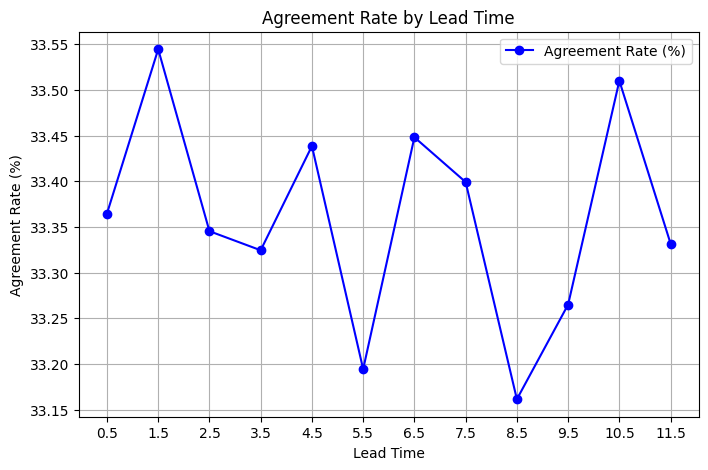

In [ ]:
# AGREEMENT RATE SHOULD FALL OFF AS LEAD TIME GOES HIGHER

# Calculate agreement rate by lead time
agreement_per_lead_time = df.groupby(['lead_time'])["agreement_rate"].mean() * 100

# Print results
agreement_per_lead_time = agreement_per_lead_time.reset_index()

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(agreement_per_lead_time["lead_time"],
         agreement_per_lead_time["agreement_rate"],
         marker="o", linestyle="-", color="b", label="Agreement Rate (%)")

# Labels and title
plt.xlabel("Lead Time")
plt.ylabel("Agreement Rate (%)")
plt.title("Agreement Rate by Lead Time")
plt.xticks(agreement_per_lead_time["lead_time"])
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 49.1 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


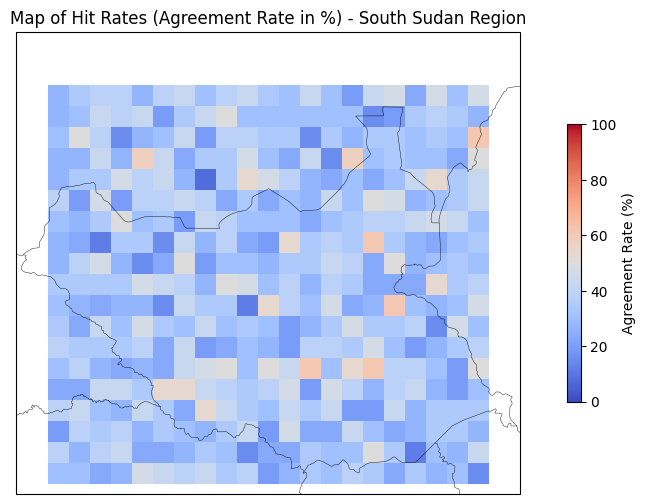

In [ ]:
# This mapping can be made into an interactive visualization, since this is all historical data

# Calculate agreement rate by pixel, for all years all months all lead times
agreement_per_pixel = df.groupby(['latitude', 'longitude', 'month', 'lead_time'])["agreement_rate"].mean() * 100

# Reset index for plotting
agreement_per_pixel = agreement_per_pixel.reset_index()

# plot the results
import matplotlib.pyplot as plt
# !pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np

# Define grid spacing
latitudes = sorted(agreement_per_pixel['latitude'].unique())
longitudes = sorted(agreement_per_pixel['longitude'].unique())

# Create a grid of values
lat_grid, lon_grid = np.meshgrid(latitudes, longitudes, indexing='ij')
agreement_grid = np.full_like(lat_grid, np.nan, dtype=np.float64)

# Fill the grid with agreement rate values
for _, row in agreement_per_pixel.iterrows():
    lat_idx = np.where(latitudes == row['latitude'])[0][0]
    lon_idx = np.where(longitudes == row['longitude'])[0][0]
    agreement_grid[lat_idx, lon_idx] = row['agreement_rate']

# Create a figure and axis with a map projection
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([24, 36, 3, 14], crs=ccrs.PlateCarree())  # Zoom into South Sudan
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# Plot the heatmap with pcolormesh
mesh = ax.pcolormesh(lon_grid, lat_grid, agreement_grid, cmap='coolwarm', vmin=0, vmax=100, shading='auto')

# Add a colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.6)
cbar.set_label('Agreement Rate (%)')

# Set title
ax.set_title('Map of Hit Rates (Agreement Rate in %) - South Sudan Region')

plt.show()

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


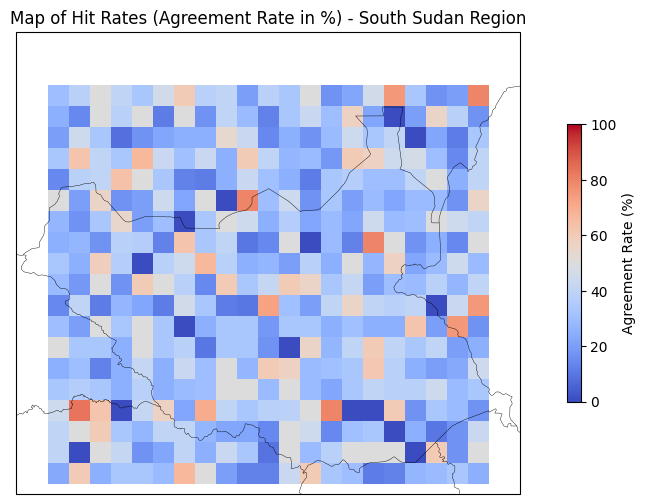

In [10]:
# another plot similar to laura's from the guidance document
# this takes all the times chirps classified precip as low, and plots the agreement rate of the model
# some of the pixels will be blank, this is when any disaggreement happens

# subset where all chirps tercile classifications are low
agreement_per_pixel_low = df[df['tercile_category_chirps'] == 'Low']

# compute agreement rate by pixel, for all years all months all lead times
agreement_per_pixel_low = agreement_per_pixel_low.groupby(['latitude', 'longitude', 'month', 'lead_time'])["agreement_rate"].mean() * 100

## reset index for plotting
agreement_per_pixel_low = agreement_per_pixel_low.reset_index()

# plot the results
import matplotlib.pyplot as plt
# !pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np

# Define grid spacing
latitudes = sorted(agreement_per_pixel_low['latitude'].unique())
longitudes = sorted(agreement_per_pixel_low['longitude'].unique())

# Create a grid of values
lat_grid, lon_grid = np.meshgrid(latitudes, longitudes, indexing='ij')
agreement_grid = np.full_like(lat_grid, np.nan, dtype=np.float64)

# Fill the grid with agreement rate values
for _, row in agreement_per_pixel_low.iterrows():
    lat_idx = np.where(latitudes == row['latitude'])[0][0]
    lon_idx = np.where(longitudes == row['longitude'])[0][0]
    agreement_grid[lat_idx, lon_idx] = row['agreement_rate']

# Create a figure and axis with a map projection
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([24, 36, 3, 14], crs=ccrs.PlateCarree())  # Zoom into South Sudan
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# Plot the heatmap with pcolormesh
mesh = ax.pcolormesh(lon_grid, lat_grid, agreement_grid, cmap='coolwarm', vmin=0, vmax=100, shading='auto')

# Add a colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.6)
cbar.set_label('Agreement Rate (%)')

# Set title
ax.set_title('Map of Hit Rates (Agreement Rate in %) - South Sudan Region')

plt.show()

In [ ]:
# CAN CALCULATE MONTHLY OR YEARLY PRECIP MEANS AND THEN TAKE TERCILES DEPENDING ON WHAT'S DESIRED
# 1997 SEPTEMBER FOR GFDL IS MISSING, NOT ON FTP
# AGREEMENT RATE IS NOT HIT RATE CORRELATION
# AGREEMENT RATE SHOULD FALL OFF AS LEAD TIME GOES HIGHER